# 03 Model Training – Arabic Abstractive Text Summarisation

This notebook trains a **Seq2Seq model with Attention** for Arabic abstractive text summarisation.

It assumes that you already finished:

- `01_data_preprocessing.ipynb`
- `02_dataset_analysis.ipynb`

Expected cleaned columns:

- `clean_article`
- `clean_summary`

Optional split column:

- `split` with values such as `train`, `valid`, `test`, `ood`


## 1. Imports

In [1]:
import os
import re
import math
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


## 2. Reproducibility and Device Setup

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device
DEVICE=device

## 3. Load Cleaned Dataset

Edit the paths below according to where your cleaned files are saved.

This notebook supports either:

1. one combined file with a `split` column, or  
2. separate files such as `train.csv`, `valid.csv`, and `test.csv`.


In [3]:
PROCESSED_DIR = Path("./dataset/processed_data")

# Option A: separate cleaned split files
TRAIN_PATH = PROCESSED_DIR / "SumArabic-train.csv"
VALID_PATH = PROCESSED_DIR / "SumArabic-test.csv"
TEST_PATH  = PROCESSED_DIR / "SumArabic-valid.csv"
OOD_PATH   = PROCESSED_DIR / "SumArabic-ood.csv"

def print_tree(path: Path, prefix: str = ""):
    """Recursively print a directory tree using pathlib."""
    if not path.exists():
        print(f"Path '{path}' does not exist.")
        return

    # Print the current directory/file name
    print(prefix + path.name)

    if path.is_dir():
        # Sort entries so directories come first
        entries = sorted(path.iterdir(), key=lambda p: (not p.is_dir(), p.name.lower()))
        for i, entry in enumerate(entries):
            connector = "└── " if i == len(entries) - 1 else "├── "
            child_prefix = prefix + ("    " if i == len(entries) - 1 else "│   ")
            print(prefix + connector + entry.name)
            if entry.is_dir():
                print_tree(entry, child_prefix)

print_tree(PROCESSED_DIR)

print("Processed directory:", PROCESSED_DIR.resolve())

processed_data
├── cleaned_Arabic_Text_Summarisation_data.csv
├── cleaned_AraSum_AbsArSumCorpus_DW_article tab lead.csv
├── cleaned_Egyptian_Text_Summarisation_data_train-00000-of-00001.csv
├── SumArabic-ood.csv
├── SumArabic-test.csv
├── SumArabic-train.csv
└── SumArabic-valid.csv
Processed directory: C:\Users\omar_Addasi\Desktop\NLP_Project\dataset\processed_data


In [4]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split


ALL_PROCESSED_FILES = [
    PROCESSED_DIR / "cleaned_Arabic_Text_Summarisation_data.csv",
    PROCESSED_DIR / "cleaned_AraSum_AbsArSumCorpus_DW_article tab lead.csv",
    PROCESSED_DIR / "cleaned_Egyptian_Text_Summarisation_data_train-00000-of-00001.csv",
    PROCESSED_DIR / "SumArabic-ood.csv",
    PROCESSED_DIR / "SumArabic-test.csv",
    PROCESSED_DIR / "SumArabic-train.csv",
    PROCESSED_DIR / "SumArabic-valid.csv",
]

RANDOM_STATE = 42
TRAIN_SIZE = 0.80
VALID_SIZE = 0.10
TEST_SIZE = 0.10


def standardize_columns(df, source_name):
    df = df.copy()

    if "clean_article" in df.columns and "clean_summary" in df.columns:
        df = df[["clean_article", "clean_summary"]].copy()

    elif "article" in df.columns and "summary" in df.columns:
        df = df[["article", "summary"]].copy()
        df = df.rename(columns={
            "article": "clean_article",
            "summary": "clean_summary"
        })

    else:
        raise ValueError(
            f"{source_name} must contain either "
            "'clean_article'/'clean_summary' or 'article'/'summary'. "
            f"Found columns: {df.columns.tolist()}"
        )

    df["source"] = source_name

    df = df.dropna(subset=["clean_article", "clean_summary"])
    df = df.drop_duplicates(subset=["clean_article", "clean_summary"])

    return df


def load_all_processed_data():
    all_dfs = []

    for path in ALL_PROCESSED_FILES:
        if path.exists():
            print("Loading:", path.name)
            temp_df = pd.read_csv(path)
            temp_df = standardize_columns(temp_df, path.stem)
            all_dfs.append(temp_df)
        else:
            print("Missing file:", path)

    if not all_dfs:
        raise FileNotFoundError("No processed files were found.")

    df = pd.concat(all_dfs, ignore_index=True)

    df = df.drop_duplicates(subset=["clean_article", "clean_summary"])
    df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

    return df


def split_dataset(df):
    train_df, temp_df = train_test_split(
        df,
        train_size=TRAIN_SIZE,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    relative_valid_size = VALID_SIZE / (VALID_SIZE + TEST_SIZE)

    valid_df, test_df = train_test_split(
        temp_df,
        train_size=relative_valid_size,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    return train_df, valid_df, test_df


df_all = load_all_processed_data()

print("\nCombined dataset:", df_all.shape)
print("\nSources:")
print(df_all["source"].value_counts())

train_df, valid_df, test_df = split_dataset(df_all)

print("\nFinal splits:")
print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test:", test_df.shape)

Loading: cleaned_Arabic_Text_Summarisation_data.csv
Loading: cleaned_AraSum_AbsArSumCorpus_DW_article tab lead.csv
Loading: cleaned_Egyptian_Text_Summarisation_data_train-00000-of-00001.csv
Loading: SumArabic-ood.csv
Loading: SumArabic-test.csv
Loading: SumArabic-train.csv
Loading: SumArabic-valid.csv

Combined dataset: (142802, 3)

Sources:
source
SumArabic-train                                                  75602
cleaned_AraSum_AbsArSumCorpus_DW_article tab lead                49578
cleaned_Arabic_Text_Summarisation_data                            5010
SumArabic-test                                                    4174
SumArabic-valid                                                   4097
cleaned_Egyptian_Text_Summarisation_data_train-00000-of-00001     3689
SumArabic-ood                                                      652
Name: count, dtype: int64

Final splits:
Train: (114241, 3)
Valid: (14280, 3)
Test: (14281, 3)


## 4. Check Required Columns

In [5]:
ARTICLE_COL = "clean_article"
SUMMARY_COL = "clean_summary"

for name, data in [("train", train_df), ("valid", valid_df), ("test", test_df)]:
    missing = [col for col in [ARTICLE_COL, SUMMARY_COL] if col not in data.columns]
    if missing:
        raise ValueError(f"{name} dataframe is missing columns: {missing}")

train_df[[ARTICLE_COL, SUMMARY_COL]].head()

,clean_article,clean_summary
5836,قال زير الدفاع الفرنسي جان ايف لو دريان اليوم ...,ما يزال مصير ضابط المخابرات الفرنسي المختطف في...
37125,يعمل باحثون استراليون على اختبار للكشف عن الاص...,اختبار للكشف عن كورونا في دقيقه باستخدام خميره...
32002,احتشد مسيحيون من مختلف انحاء العالم في كنيسه ا...,شارك الاف من المسيحيين في احتفالات عيد الفصح ا...
50365,استضاف فرج بن حموده بن علي الظاهري في منزله بم...,مجلس زايد يستذكر دور المؤسس في اقامه دوله العد...
85111,اعلن القضاء الاميركي الخميس كانون الثاني يناير...,اعلن القضاء الاميركي انشاء حده خاصه للتحقيق في...


## 5. Basic Filtering for Training

For a first Seq2Seq model, avoid extremely long samples because they make training slow and memory-heavy.

You can adjust these values later.


In [6]:
MAX_ARTICLE_TOKENS = 300
MAX_SUMMARY_TOKENS = 40
MIN_ARTICLE_TOKENS = 5
MIN_SUMMARY_TOKENS = 2

def count_tokens(text):
    return len(str(text).split())

def filter_by_length(df):
    df = df.copy()
    df["article_len"] = df[ARTICLE_COL].apply(count_tokens)
    df["summary_len"] = df[SUMMARY_COL].apply(count_tokens)

    df = df[
        (df["article_len"] >= MIN_ARTICLE_TOKENS) &
        (df["summary_len"] >= MIN_SUMMARY_TOKENS) &
        (df["article_len"] <= MAX_ARTICLE_TOKENS) &
        (df["summary_len"] <= MAX_SUMMARY_TOKENS)
    ].copy()

    return df

train_df = filter_by_length(train_df)
valid_df = filter_by_length(valid_df)
test_df = filter_by_length(test_df)

print("After filtering:")
print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test:", test_df.shape)

After filtering:
Train: (92751, 5)
Valid: (11642, 5)
Test: (11580, 5)


## 7. Vocabulary Building

Special tokens:

- `<PAD>` padding
- `<UNK>` unknown token
- `<SOS>` start of summary
- `<EOS>` end of summary


In [7]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"

PAD_IDX = 0
UNK_IDX = 1
SOS_IDX = 2
EOS_IDX = 3

SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN]

MAX_VOCAB_SIZE = 30000
MIN_FREQ = 2

def tokenize(text):
    return str(text).split()

def build_vocab(texts, max_vocab_size=MAX_VOCAB_SIZE, min_freq=MIN_FREQ):
    counter = Counter()

    for text in texts:
        counter.update(tokenize(text))

    vocab = SPECIAL_TOKENS.copy()

    for word, freq in counter.most_common():
        if freq < min_freq:
            continue
        if word in vocab:
            continue
        vocab.append(word)
        if len(vocab) >= max_vocab_size:
            break

    word2idx = {word: idx for idx, word in enumerate(vocab)}
    idx2word = {idx: word for word, idx in word2idx.items()}

    return word2idx, idx2word, counter

source_word2idx, source_idx2word, source_counter = build_vocab(train_df[ARTICLE_COL])
target_word2idx, target_idx2word, target_counter = build_vocab(train_df[SUMMARY_COL])

print("Source vocab size:", len(source_word2idx))
print("Target vocab size:", len(target_word2idx))

Source vocab size: 30000
Target vocab size: 30000


## 8. Convert Text to Sequences

In [8]:
ENCODER_MAX_LEN = MAX_ARTICLE_TOKENS
DECODER_MAX_LEN = MAX_SUMMARY_TOKENS + 2  # includes SOS and EOS

def text_to_source_sequence(text):
    tokens = tokenize(text)[:ENCODER_MAX_LEN]
    ids = [source_word2idx.get(tok, UNK_IDX) for tok in tokens]
    return ids

def text_to_target_sequence(text):
    tokens = tokenize(text)[:MAX_SUMMARY_TOKENS]
    ids = [target_word2idx.get(tok, UNK_IDX) for tok in tokens]
    return [SOS_IDX] + ids + [EOS_IDX]

def pad_sequence(seq, max_len, pad_idx=PAD_IDX):
    if len(seq) < max_len:
        seq = seq + [pad_idx] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

## 9. Dataset and DataLoader

In [9]:
class SummarisationDataset(Dataset):
    def __init__(self, df):
        self.articles = df[ARTICLE_COL].astype(str).tolist()
        self.summaries = df[SUMMARY_COL].astype(str).tolist()

    def __len__(self):
        return len(self.articles)

    def __getitem__(self, idx):
        source_seq = text_to_source_sequence(self.articles[idx])
        target_seq = text_to_target_sequence(self.summaries[idx])

        source_seq = pad_sequence(source_seq, ENCODER_MAX_LEN)
        target_seq = pad_sequence(target_seq, DECODER_MAX_LEN)

        source_tensor = torch.tensor(source_seq, dtype=torch.long)
        target_tensor = torch.tensor(target_seq, dtype=torch.long)

        return source_tensor, target_tensor

BATCH_SIZE = 32

train_dataset = SummarisationDataset(train_df)
valid_dataset = SummarisationDataset(valid_df)
test_dataset = SummarisationDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

source_batch, target_batch = next(iter(train_loader))
print("Source batch:", source_batch.shape)
print("Target batch:", target_batch.shape)

Source batch: torch.Size([32, 300])
Target batch: torch.Size([32, 42])


## 10. Seq2Seq with Bahdanau Attention

In [10]:
import torch
import torch.nn as nn
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ========================
# ENCODER
# ========================
def create_encoder(input_dim, emb_dim, hidden_dim, num_layers=2, dropout=0.4):
    """Create a bidirectional multi-layer GRU encoder."""
    return {
        "embedding": nn.Embedding(input_dim, emb_dim, padding_idx=PAD_IDX).to(device),
        "rnn": nn.GRU(
            emb_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        ).to(device),
        "fc": nn.Linear(hidden_dim * 2, hidden_dim).to(device),
        "dropout": nn.Dropout(dropout),
        "num_layers": num_layers
    }


def encoder_forward(encoder, src):
    embedded = encoder["dropout"](encoder["embedding"](src))
    outputs, hidden = encoder["rnn"](embedded)

    # hidden shape for bidirectional GRU:
    # [num_layers * 2, batch, hidden_dim]
    # We use the final encoder layer's forward and backward states.
    hidden_forward = hidden[-2]
    hidden_backward = hidden[-1]

    hidden_cat = torch.cat((hidden_forward, hidden_backward), dim=1)
    hidden = torch.tanh(encoder["fc"](hidden_cat))

    # Decoder is also multi-layer. Repeat the final encoder context for each decoder layer.
    decoder_layers = encoder.get("decoder_num_layers", encoder["num_layers"])
    hidden = hidden.unsqueeze(0).repeat(decoder_layers, 1, 1)

    return outputs, hidden


# ========================
# ATTENTION
# ========================
def create_attention(encoder_hidden_dim, decoder_hidden_dim):
    return {
        "attn": nn.Linear((encoder_hidden_dim * 2) + decoder_hidden_dim, decoder_hidden_dim).to(device),
        "v": nn.Linear(decoder_hidden_dim, 1, bias=False).to(device)
    }


def attention_forward(attention, hidden, encoder_outputs, mask):
    src_len = encoder_outputs.shape[1]

    # Use the top decoder layer for attention.
    hidden = hidden[-1].unsqueeze(1).repeat(1, src_len, 1)

    energy = torch.tanh(
        attention["attn"](torch.cat((hidden, encoder_outputs), dim=2))
    )

    attention_scores = attention["v"](energy).squeeze(2)
    attention_scores = attention_scores.masked_fill(mask == 0, -1e10)

    return torch.softmax(attention_scores, dim=1)


# ========================
# DECODER
# ========================
def create_decoder(output_dim, emb_dim, encoder_hidden_dim, decoder_hidden_dim, attention, num_layers=2, dropout=0.4):
    """Create a multi-layer GRU decoder with Bahdanau-style attention."""
    return {
        "output_dim": output_dim,
        "attention": attention,
        "embedding": nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX).to(device),
        "rnn": nn.GRU(
            (encoder_hidden_dim * 2) + emb_dim,
            decoder_hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        ).to(device),
        "fc_out": nn.Linear(
            (encoder_hidden_dim * 2) + decoder_hidden_dim + emb_dim,
            output_dim
        ).to(device),
        "dropout": nn.Dropout(dropout),
        "num_layers": num_layers
    }


def decoder_forward(decoder, input_token, hidden, encoder_outputs, mask):
    input_token = input_token.unsqueeze(1)

    embedded = decoder["dropout"](decoder["embedding"](input_token))

    attention_weights = attention_forward(
        decoder["attention"],
        hidden,
        encoder_outputs,
        mask
    )

    attention_weights = attention_weights.unsqueeze(1)
    weighted = torch.bmm(attention_weights, encoder_outputs)

    rnn_input = torch.cat((embedded, weighted), dim=2)
    output, hidden = decoder["rnn"](rnn_input, hidden)

    embedded = embedded.squeeze(1)
    output = output.squeeze(1)
    weighted = weighted.squeeze(1)

    prediction = decoder["fc_out"](
        torch.cat((output, weighted, embedded), dim=1)
    )

    return prediction, hidden, attention_weights.squeeze(1)


# ========================
# SEQ2SEQ
# ========================
def create_seq2seq(encoder, decoder, src_pad_idx=PAD_IDX):
    # Keep decoder layer count in encoder so encoder_forward can initialize decoder hidden state correctly.
    encoder["decoder_num_layers"] = decoder.get("num_layers", encoder.get("num_layers", 1))
    return {
        "encoder": encoder,
        "decoder": decoder,
        "src_pad_idx": src_pad_idx
    }


def create_mask(model, src):
    return src != model["src_pad_idx"]


def seq2seq_forward(model, src, trg, teacher_forcing_ratio=0.5):
    batch_size = src.shape[0]
    trg_len = trg.shape[1]
    trg_vocab_size = model["decoder"]["output_dim"]

    outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(src.device)

    encoder_outputs, hidden = encoder_forward(model["encoder"], src)
    mask = create_mask(model, src)

    input_token = trg[:, 0]

    for t in range(1, trg_len):
        output, hidden, _ = decoder_forward(
            model["decoder"],
            input_token,
            hidden,
            encoder_outputs,
            mask
        )

        outputs[:, t, :] = output

        teacher_force = random.random() < teacher_forcing_ratio
        top1 = output.argmax(1)

        input_token = trg[:, t] if teacher_force else top1

    return outputs


# ========================
# PARAMETERS
# ========================
def get_model_parameters(model):
    params = []

    for module in [
        model["encoder"]["embedding"],
        model["encoder"]["rnn"],
        model["encoder"]["fc"],
        model["decoder"]["embedding"],
        model["decoder"]["rnn"],
        model["decoder"]["fc_out"],
        model["decoder"]["attention"]["attn"],
        model["decoder"]["attention"]["v"]
    ]:
        params += list(module.parameters())

    return params


def count_parameters(model):
    return sum(p.numel() for p in get_model_parameters(model) if p.requires_grad)


## 11. Initialise Model

In [11]:
INPUT_DIM = len(source_word2idx)
OUTPUT_DIM = len(target_word2idx)

ENC_EMB_DIM = 128
DEC_EMB_DIM = 128
ENC_HID_DIM = 256
DEC_HID_DIM = 256
ENC_NUM_LAYERS = 2
DEC_NUM_LAYERS = 2
DROPOUT = 0.4

# Create attention, encoder, decoder, and Seq2Seq model using a 2-layer GRU encoder/decoder.
attention = create_attention(ENC_HID_DIM, DEC_HID_DIM)

encoder = create_encoder(
    input_dim=INPUT_DIM,
    emb_dim=ENC_EMB_DIM,
    hidden_dim=ENC_HID_DIM,
    num_layers=ENC_NUM_LAYERS,
    dropout=DROPOUT
)

decoder = create_decoder(
    output_dim=OUTPUT_DIM,
    emb_dim=DEC_EMB_DIM,
    encoder_hidden_dim=ENC_HID_DIM,
    decoder_hidden_dim=DEC_HID_DIM,
    attention=attention,
    num_layers=DEC_NUM_LAYERS,
    dropout=DROPOUT
)

model = create_seq2seq(encoder, decoder)

print("Model depth:")
print("Encoder GRU layers:", ENC_NUM_LAYERS)
print("Decoder GRU layers:", DEC_NUM_LAYERS)
print(f"Trainable parameters: {count_parameters(model):,}")


Model depth:
Encoder GRU layers: 2
Decoder GRU layers: 2
Trainable parameters: 37,778,480


In [12]:
import torch

print("Torch:", torch.__version__)
print("Torch CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("Capability:", torch.cuda.get_device_capability(0))

Torch: 2.11.0+cu128
Torch CUDA: 12.8
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Ti
Capability: (12, 0)


## 12. Training Setup

In [13]:
optimizer = torch.optim.Adam(get_model_parameters(model), lr=0.0005)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

CLIP = 1.0
N_EPOCHS = 12
TEACHER_FORCING_RATIO = 0.5

# Early stopping configuration
PATIENCE = 3
MIN_DELTA = 0.0

MODEL_DIR = Path("./models")
MODEL_DIR.mkdir(exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "best_seq2seq_attention_2layer.pt"

print("Training configuration:")
print("Device:", device)
print("Epochs:", N_EPOCHS)
print("Patience:", PATIENCE)
print("Learning rate:", 0.0005)
print("Best model path:", BEST_MODEL_PATH.resolve())


Training configuration:
Device: cuda
Epochs: 12
Patience: 3
Learning rate: 0.0005
Best model path: C:\Users\omar_Addasi\Desktop\NLP_Project\models\best_seq2seq_attention_2layer.pt


## 13. Training and Evaluation Functions

In [14]:

def set_train_mode(model):
    """Set all module components in the dictionary-based model to training mode."""
    for component in [
        model["encoder"]["embedding"],
        model["encoder"]["rnn"],
        model["encoder"]["fc"],
        model["decoder"]["embedding"],
        model["decoder"]["rnn"],
        model["decoder"]["fc_out"],
        model["decoder"]["attention"]["attn"],
        model["decoder"]["attention"]["v"]
    ]:
        component.train()


def set_eval_mode(model):
    """Set all module components in the dictionary-based model to evaluation mode."""
    for component in [
        model["encoder"]["embedding"],
        model["encoder"]["rnn"],
        model["encoder"]["fc"],
        model["decoder"]["embedding"],
        model["decoder"]["rnn"],
        model["decoder"]["fc_out"],
        model["decoder"]["attention"]["attn"],
        model["decoder"]["attention"]["v"]
    ]:
        component.eval()


def train_one_epoch(model, dataloader, optimizer, criterion, clip=1.0):
    set_train_mode(model)
    epoch_loss = 0

    for src, trg in dataloader:
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        output = seq2seq_forward(
            model,
            src,
            trg,
            teacher_forcing_ratio=TEACHER_FORCING_RATIO
        )

        # output: [batch, trg_len, output_dim]
        output_dim = output.shape[-1]

        output = output[:, 1:, :].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(get_model_parameters(model), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)


def evaluate(model, dataloader, criterion):
    set_eval_mode(model)
    epoch_loss = 0

    with torch.no_grad():
        for src, trg in dataloader:
            src = src.to(device)
            trg = trg.to(device)

            output = seq2seq_forward(
                model,
                src,
                trg,
                teacher_forcing_ratio=0.0
            )

            output_dim = output.shape[-1]
            output = output[:, 1:, :].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)

            loss = criterion(output, trg)
            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)


## 14. Train the Model

In [15]:
import math

train_losses = []
valid_losses = []

best_valid_loss = float("inf")
patience_counter = 0


def set_train_mode(model):
    for component in [
        model["encoder"]["embedding"],
        model["encoder"]["rnn"],
        model["encoder"]["fc"],
        model["decoder"]["embedding"],
        model["decoder"]["rnn"],
        model["decoder"]["fc_out"],
        model["decoder"]["attention"]["attn"],
        model["decoder"]["attention"]["v"]
    ]:
        component.train()


def set_eval_mode(model):
    for component in [
        model["encoder"]["embedding"],
        model["encoder"]["rnn"],
        model["encoder"]["fc"],
        model["decoder"]["embedding"],
        model["decoder"]["rnn"],
        model["decoder"]["fc_out"],
        model["decoder"]["attention"]["attn"],
        model["decoder"]["attention"]["v"]
    ]:
        component.eval()


for epoch in range(1, N_EPOCHS + 1):

    set_train_mode(model)
    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        CLIP
    )

    set_eval_mode(model)
    valid_loss = evaluate(
        model,
        valid_loader,
        criterion
    )

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f"Epoch {epoch:02d}")
    print(f"Train Loss: {train_loss:.4f} | Train PPL: {math.exp(train_loss):.2f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid PPL: {math.exp(valid_loss):.2f}")

    if valid_loss < best_valid_loss - MIN_DELTA:
        best_valid_loss = valid_loss
        patience_counter = 0

        torch.save({
            "encoder": {
                "embedding": model["encoder"]["embedding"].state_dict(),
                "rnn": model["encoder"]["rnn"].state_dict(),
                "fc": model["encoder"]["fc"].state_dict()
            },
            "decoder": {
                "embedding": model["decoder"]["embedding"].state_dict(),
                "rnn": model["decoder"]["rnn"].state_dict(),
                "fc_out": model["decoder"]["fc_out"].state_dict(),
                "attention_attn": model["decoder"]["attention"]["attn"].state_dict(),
                "attention_v": model["decoder"]["attention"]["v"].state_dict()
            },
            "source_word2idx": source_word2idx,
            "source_idx2word": source_idx2word,
            "target_word2idx": target_word2idx,
            "target_idx2word": target_idx2word,
            "best_epoch": epoch,
            "best_valid_loss": best_valid_loss,
            "config": {
                "encoder_max_len": ENCODER_MAX_LEN,
                "decoder_max_len": DECODER_MAX_LEN,
                "input_dim": INPUT_DIM,
                "output_dim": OUTPUT_DIM,
                "enc_emb_dim": ENC_EMB_DIM,
                "dec_emb_dim": DEC_EMB_DIM,
                "enc_hidden_dim": ENC_HID_DIM,
                "dec_hidden_dim": DEC_HID_DIM,
                "enc_num_layers": ENC_NUM_LAYERS,
                "dec_num_layers": DEC_NUM_LAYERS,
                "dropout": DROPOUT,
                "teacher_forcing_ratio": TEACHER_FORCING_RATIO
            }
        }, BEST_MODEL_PATH)

        print("Best model saved.")

    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{PATIENCE}")

    print("-" * 60)

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break


print("Best validation loss:", best_valid_loss)
print("Saved best model to:", BEST_MODEL_PATH.resolve())


Epoch 01
Train Loss: 7.2908 | Train PPL: 1466.69
Valid Loss: 6.8513 | Valid PPL: 945.15
Best model saved.
------------------------------------------------------------
Epoch 02
Train Loss: 6.3960 | Train PPL: 599.43
Valid Loss: 6.5834 | Valid PPL: 722.98
Best model saved.
------------------------------------------------------------
Epoch 03
Train Loss: 5.9296 | Train PPL: 376.02
Valid Loss: 6.5123 | Valid PPL: 673.34
Best model saved.
------------------------------------------------------------
Epoch 04
Train Loss: 5.5941 | Train PPL: 268.83
Valid Loss: 6.4747 | Valid PPL: 648.50
Best model saved.
------------------------------------------------------------
Epoch 05
Train Loss: 5.3254 | Train PPL: 205.49
Valid Loss: 6.5043 | Valid PPL: 667.98
No improvement. Patience: 1/3
------------------------------------------------------------
Epoch 06
Train Loss: 5.0955 | Train PPL: 163.29
Valid Loss: 6.5323 | Valid PPL: 686.96
No improvement. Patience: 2/3
----------------------------------------

## 15. Plot Training Curves

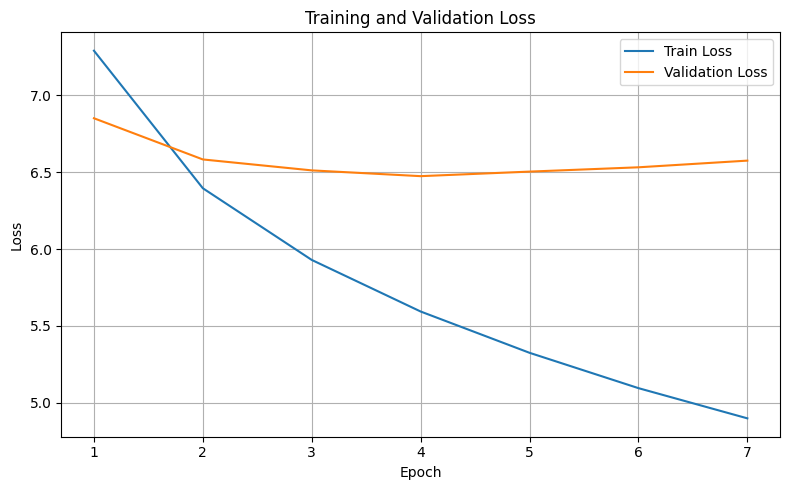

Saved loss curve to: C:\Users\omar_Addasi\Desktop\NLP_Project\results\loss_curve.png


In [16]:
RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)

epochs = list(range(1, len(train_losses) + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, valid_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_plot_path = RESULTS_DIR / "loss_curve.png"
plt.savefig(loss_plot_path, dpi=200)
plt.show()

print("Saved loss curve to:", loss_plot_path.resolve())


## 16. Load Best Model

In [17]:
def load_checkpoint_into_model(model, checkpoint):
    """Load saved state dictionaries into the dictionary-based Seq2Seq model."""
    model["encoder"]["embedding"].load_state_dict(checkpoint["encoder"]["embedding"])
    model["encoder"]["rnn"].load_state_dict(checkpoint["encoder"]["rnn"])
    model["encoder"]["fc"].load_state_dict(checkpoint["encoder"]["fc"])

    model["decoder"]["embedding"].load_state_dict(checkpoint["decoder"]["embedding"])
    model["decoder"]["rnn"].load_state_dict(checkpoint["decoder"]["rnn"])
    model["decoder"]["fc_out"].load_state_dict(checkpoint["decoder"]["fc_out"])
    model["decoder"]["attention"]["attn"].load_state_dict(checkpoint["decoder"]["attention_attn"])
    model["decoder"]["attention"]["v"].load_state_dict(checkpoint["decoder"]["attention_v"])

    return model


checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model = load_checkpoint_into_model(model, checkpoint)
set_eval_mode(model)

print("Best model loaded.")
print("Best epoch:", checkpoint.get("best_epoch", "not saved"))
print("Best validation loss:", checkpoint.get("best_valid_loss", "not saved"))


Best model loaded.
Best epoch: 4
Best validation loss: 6.474663746225965


In [18]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.11.0+cu128
12.8
True


## 17. Generate Summaries

This uses greedy decoding. Beam search can be added later for better summaries.


In [19]:
def sequence_to_text(indices, idx2word):
    words = []
    for idx in indices:
        word = idx2word.get(int(idx), UNK_TOKEN)
        if word == EOS_TOKEN:
            break
        if word not in [PAD_TOKEN, SOS_TOKEN, UNK_TOKEN]:
            words.append(word)
    return " ".join(words)

def extract_keywords(text, top_k=20):
    words = text.split()
    freq = {}

    for w in words:
        freq[w] = freq.get(w, 0) + 1

    sorted_words = sorted(freq.items(), key=lambda x: x[1], reverse=True)
    return set([w for w, _ in sorted_words[:top_k]])
# Recall-focused generation:
# - longer maximum length
# - higher minimum length before allowing EOS
# - slightly wider top-k for more coverage
# - softer repetition penalty so the model can include useful repeated entities when needed
# - immediate-repeat and repeated-bigram blocking to reduce loops like "ابوظبي ابوظبي"
def postprocess_summary(summary):
    words = summary.split()
    cleaned = []

    for w in words:
        # Remove only immediate repetition
        if cleaned and cleaned[-1] == w:
            continue

        # Avoid excessive repetition of same content word
        # but allow function words/prepositions
        function_words = {"في", "من", "على", "الى", "إلى", "عن", "مع", "و", "ب", "ل"}

        if w not in function_words:
            if cleaned.count(w) >= 1:
                continue

        cleaned.append(w)

    return " ".join(cleaned)
import torch.nn.functional as F

def summarise_text(
    text,
    max_len=15,
    min_len=4,
    temperature=0.7,
    top_k=50,
    top_p=0.9,
    repetition_penalty=1.2
):
    set_eval_mode(model)

    src_tokens = text.split()[:ENCODER_MAX_LEN]
    src_ids = [source_word2idx.get(token, UNK_IDX) for token in src_tokens]
    src_ids = src_ids + [PAD_IDX] * (ENCODER_MAX_LEN - len(src_ids))
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)

    generated_ids = []
    generated_words = []
    
    # Extract keywords for mild boosting
    freq = {}
    for w in src_tokens:
        freq[w] = freq.get(w, 0) + 1
    keywords = set(sorted(freq, key=freq.get, reverse=True)[:15])

    with torch.no_grad():
        encoder_outputs, hidden = encoder_forward(model["encoder"], src_tensor)
        mask = create_mask(model, src_tensor)
        input_token = torch.tensor([SOS_IDX], dtype=torch.long).to(DEVICE)

        for step in range(max_len):
            output, hidden, _ = decoder_forward(
                model["decoder"],
                input_token,
                hidden,
                encoder_outputs,
                mask
            )

            logits = output.squeeze(0).clone()

            # 1. Block unwanted tokens
            logits[PAD_IDX] = -float('Inf')
            logits[SOS_IDX] = -float('Inf')
            logits[UNK_IDX] = -float('Inf')
            if step < min_len:
                logits[EOS_IDX] = -float('Inf')

            # 2. Standard Repetition Penalty (Divisive/Multiplicative based on sign)
            for token_id in set(generated_ids):
                if logits[token_id] > 0:
                    logits[token_id] /= repetition_penalty
                else:
                    logits[token_id] *= repetition_penalty
                    
            # 3. Mild keyword boost (Additive instead of Multiplicative)
            for idx in range(len(logits)):
                word = target_idx2word.get(idx, "")
                if word in keywords:
                    logits[idx] += 1.0 
            
            # 4. Temperature Scaling
            logits = logits / temperature
            
            # 5. Top-K & Top-P (Nucleus) Sampling
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[-1]] = -float('Inf')
            
            probs = F.softmax(logits, dim=-1)
            
            sorted_probs, sorted_indices = torch.sort(probs, descending=True)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
            
            sorted_indices_to_remove = cumulative_probs > top_p
            sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
            sorted_indices_to_remove[..., 0] = 0
            
            indices_to_remove = sorted_indices[sorted_indices_to_remove]
            logits[indices_to_remove] = -float('Inf')
            
            filtered_probs = F.softmax(logits, dim=-1)
            
            # Sample next token
            next_token = torch.multinomial(filtered_probs, 1).item()

            if next_token == EOS_IDX:
                break

            generated_ids.append(next_token)
            word = target_idx2word.get(next_token, "")
            
            if word not in ["<pad>", "<sos>", "<eos>", "<unk>", ""]:
                generated_words.append(word)

            input_token = torch.tensor([next_token], dtype=torch.long).to(DEVICE)

    return postprocess_summary(" ".join(generated_words))

## 18. Test on Sample Articles

In [20]:
QUALITATIVE_SAMPLE_SIZE = 10

sample_rows = test_df.sample(min(QUALITATIVE_SAMPLE_SIZE, len(test_df)), random_state=SEED)

qualitative_results = []

for i, row in sample_rows.iterrows():
    article = str(row[ARTICLE_COL])
    reference = str(row[SUMMARY_COL])
    generated = summarise_text(article)

    qualitative_results.append({
        "article": article,
        "reference_summary": reference,
        "generated_summary": generated
    })

    print("=" * 100)
    print("ARTICLE:")
    print(article[:1000])
    print("\nREFERENCE SUMMARY:")
    print(reference)
    print("\nGENERATED SUMMARY:")
    print(generated)

qualitative_df = pd.DataFrame(qualitative_results)
qualitative_path = RESULTS_DIR / "qualitative_sample_predictions.csv"
qualitative_df.to_csv(qualitative_path, index=False, encoding="utf-8-sig")

print("Saved qualitative samples to:", qualitative_path.resolve())
display(qualitative_df.head())


ARTICLE:
قال مدير اداره عمليات المسافرين في جمارك دبي ابراهيم الكمالي ان الاداره حققت زياده كبيره في ضبطياتها لماده زيت المارغوانا المخدره التي تستخدم بواسطه السجائر الالكترونيه اذ وصل عدد ضبطياتها خلال الربع الاول من العام الجاري الى ضبطيه مقارنه بسبع ضبطيات في الربع الاول من العام الماضي علما بان عدد الضبطيات المسجله خلال العام الماضي باكمله بلغ ضبطيه

REFERENCE SUMMARY:
ضبطيه لاحباط دخول مخدر زيت المارغوانا الى الدوله

GENERATED SUMMARY:
ارتفاع في دبي خلال العام الماضي
ARTICLE:
احيى الفلسطينيون اليوم الجمعه الذكرى السنويه يوم النكبه من دون فعاليات شعبيه في سابقه هي الاولى ذلك بسبب التدابير المتخذه لمنع تفشي فيروس كورونا المستجد

REFERENCE SUMMARY:
الفلسطينيون يحيون يوم النكبه بدون فعاليات لاول مره بسبب كورونا

GENERATED SUMMARY:
تايلاند اليوم من في
ARTICLE:
اشار خبراء الى ان الاجر الذي تحصل عليه المراه الامريكيه لن يتساوى مع الاجر الذي يحصل عليه الرجل عن نفس العمل الا بعد عاما اذا ظل معدل تحسين الاجر عند مستواه الحالي وهي قضيه ابرزها الرئيس الامريكي باراك اوباما في خطابه عن حاله الا

,article,reference_summary,generated_summary
0,قال مدير اداره عمليات المسافرين في جمارك دبي ا...,ضبطيه لاحباط دخول مخدر زيت المارغوانا الى الدوله,ارتفاع في دبي خلال العام الماضي
1,احيى الفلسطينيون اليوم الجمعه الذكرى السنويه ي...,الفلسطينيون يحيون يوم النكبه بدون فعاليات لاول...,تايلاند اليوم من في
2,اشار خبراء الى ان الاجر الذي تحصل عليه المراه ...,اوضح خبراء امريكيون ان الاجر الذي تحصل عليه ال...,اظهر مؤسسه الذي من في الى المراه العالمي في عن...
3,نظم المجلس الوطني للاعلام احتفالا باليوم الوطن...,الامارات تحتفل باليوم الوطني الرمزي في اكسبو ب...,الوطني في المجلس
4,تبنى البرلمان الفرنسي الخميس بشكل نهائي فرض ضر...,فرض ضريبه على مجموعات رقميه عملاقه,البرلمان الاوروبي على البريطاني للبرلمان


## 19. ROUGE Evaluation

This section evaluates the generated summaries using:

- ROUGE-1
- ROUGE-2
- ROUGE-L

The notebook will automatically install `rouge-score` if it is missing.


In [21]:
def normalize_for_rouge(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_arabic(text):
    return normalize_for_rouge(text).split()


def precision_recall_f1(overlap, ref_count, gen_count):
    if ref_count == 0 or gen_count == 0 or overlap == 0:
        return 0.0, 0.0, 0.0

    precision = overlap / gen_count
    recall = overlap / ref_count
    f1 = 2 * precision * recall / (precision + recall)

    return precision, recall, f1


def get_ngrams(tokens, n):
    if len(tokens) < n:
        return []
    return list(zip(*[tokens[i:] for i in range(n)]))


def rouge1_arabic_scores(reference, generated):
    ref_tokens = tokenize_arabic(reference)
    gen_tokens = tokenize_arabic(generated)

    ref_set = set(ref_tokens)
    gen_set = set(gen_tokens)

    overlap = len(ref_set & gen_set)
    return precision_recall_f1(overlap, len(ref_set), len(gen_set))


def rouge2_arabic_scores(reference, generated):
    ref_tokens = tokenize_arabic(reference)
    gen_tokens = tokenize_arabic(generated)

    ref_bigrams = set(get_ngrams(ref_tokens, 2))
    gen_bigrams = set(get_ngrams(gen_tokens, 2))

    overlap = len(ref_bigrams & gen_bigrams)
    return precision_recall_f1(overlap, len(ref_bigrams), len(gen_bigrams))


def lcs_length(x, y):
    m, n = len(x), len(y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m):
        for j in range(n):
            if x[i] == y[j]:
                dp[i + 1][j + 1] = dp[i][j] + 1
            else:
                dp[i + 1][j + 1] = max(dp[i][j + 1], dp[i + 1][j])

    return dp[m][n]


def rougeL_arabic_scores(reference, generated):
    ref_tokens = tokenize_arabic(reference)
    gen_tokens = tokenize_arabic(generated)

    lcs = lcs_length(ref_tokens, gen_tokens)
    return precision_recall_f1(lcs, len(ref_tokens), len(gen_tokens))


def evaluate_rouge(df, max_samples=500):
    print("ARTICLE_COL:", ARTICLE_COL)
    print("SUMMARY_COL:", SUMMARY_COL)
    print("Available columns:", df.columns.tolist())

    required_cols = [ARTICLE_COL, SUMMARY_COL]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")

    if max_samples is None:
        sample_df = df.copy()
    else:
        sample_df = df.sample(min(max_samples, len(df)), random_state=SEED).copy()

    sample_df = sample_df.reset_index(drop=True)

    scores = {
        "rouge1_precision_arabic": [],
        "rouge1_recall_arabic": [],
        "rouge1_f1_arabic": [],
        "rouge2_precision_arabic": [],
        "rouge2_recall_arabic": [],
        "rouge2_f1_arabic": [],
        "rougeL_precision_arabic": [],
        "rougeL_recall_arabic": [],
        "rougeL_f1_arabic": []
    }

    prediction_rows = []

    for n, row in sample_df.iterrows():
        article = normalize_for_rouge(row[ARTICLE_COL])
        reference = normalize_for_rouge(row[SUMMARY_COL])
        generated = normalize_for_rouge(summarise_text(article))

        r1_p, r1_r, r1_f = rouge1_arabic_scores(reference, generated)
        r2_p, r2_r, r2_f = rouge2_arabic_scores(reference, generated)
        rl_p, rl_r, rl_f = rougeL_arabic_scores(reference, generated)

        scores["rouge1_precision_arabic"].append(r1_p)
        scores["rouge1_recall_arabic"].append(r1_r)
        scores["rouge1_f1_arabic"].append(r1_f)
        scores["rouge2_precision_arabic"].append(r2_p)
        scores["rouge2_recall_arabic"].append(r2_r)
        scores["rouge2_f1_arabic"].append(r2_f)
        scores["rougeL_precision_arabic"].append(rl_p)
        scores["rougeL_recall_arabic"].append(rl_r)
        scores["rougeL_f1_arabic"].append(rl_f)

        prediction_rows.append({
            "row_id": n,
            "article": article,
            "reference_summary": reference,
            "generated_summary": generated,
            "rouge1_precision_arabic": r1_p,
            "rouge1_recall_arabic": r1_r,
            "rouge1_f1_arabic": r1_f,
            "rouge2_precision_arabic": r2_p,
            "rouge2_recall_arabic": r2_r,
            "rouge2_f1_arabic": r2_f,
            "rougeL_precision_arabic": rl_p,
            "rougeL_recall_arabic": rl_r,
            "rougeL_f1_arabic": rl_f
        })

        if (n + 1) % 25 == 0:
            print(f"Evaluated {n + 1}/{len(sample_df)} samples...")

    rouge_results = {key: float(np.mean(values)) for key, values in scores.items()}
    rouge_results["num_samples"] = len(sample_df)

    return rouge_results, pd.DataFrame(prediction_rows)


ROUGE_MAX_SAMPLES = 200

rouge_results, prediction_df = evaluate_rouge(test_df, max_samples=ROUGE_MAX_SAMPLES)

print("Arabic-safe ROUGE results with precision/recall/F1:")
for metric, value in rouge_results.items():
    if metric == "num_samples":
        print(f"{metric}: {value}")
    else:
        print(f"{metric}: {value:.4f}")

rouge_path = RESULTS_DIR / "rouge_scores_arabic_recall_focused.csv"
pred_path = RESULTS_DIR / "test_predictions_with_arabic_rouge_recall_focused.csv"

pd.DataFrame([rouge_results]).to_csv(rouge_path, index=False, encoding="utf-8-sig")
prediction_df.to_csv(pred_path, index=False, encoding="utf-8-sig")

print("Saved Arabic-safe ROUGE scores to:", rouge_path.resolve())
print("Saved predictions to:", pred_path.resolve())

display(prediction_df.head())


ARTICLE_COL: clean_article
SUMMARY_COL: clean_summary
Available columns: ['clean_article', 'clean_summary', 'source', 'article_len', 'summary_len']
Evaluated 25/200 samples...
Evaluated 50/200 samples...
Evaluated 75/200 samples...
Evaluated 100/200 samples...
Evaluated 125/200 samples...
Evaluated 150/200 samples...
Evaluated 175/200 samples...
Evaluated 200/200 samples...
Arabic-safe ROUGE results with precision/recall/F1:
rouge1_precision_arabic: 0.3186
rouge1_recall_arabic: 0.2066
rouge1_f1_arabic: 0.2393
rouge2_precision_arabic: 0.0705
rouge2_recall_arabic: 0.0517
rouge2_f1_arabic: 0.0565
rougeL_precision_arabic: 0.2659
rougeL_recall_arabic: 0.1803
rougeL_f1_arabic: 0.2053
num_samples: 200
Saved Arabic-safe ROUGE scores to: C:\Users\omar_Addasi\Desktop\NLP_Project\results\rouge_scores_arabic_recall_focused.csv
Saved predictions to: C:\Users\omar_Addasi\Desktop\NLP_Project\results\test_predictions_with_arabic_rouge_recall_focused.csv


,row_id,article,reference_summary,generated_summary,rouge1_precision_arabic,rouge1_recall_arabic,rouge1_f1_arabic,rouge2_precision_arabic,rouge2_recall_arabic,rouge2_f1_arabic,rougeL_precision_arabic,rougeL_recall_arabic,rougeL_f1_arabic
0,0,قال مدير اداره عمليات المسافرين في جمارك دبي ا...,ضبطيه لاحباط دخول مخدر زيت المارغوانا الى الدوله,نسبه اشغال في مصنع دبي خلال الربع,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,1,احيى الفلسطينيون اليوم الجمعه الذكرى السنويه ي...,الفلسطينيون يحيون يوم النكبه بدون فعاليات لاول...,فيتنام اليوم الجمعه في يوم من في كورونا,0.285714,0.200000,0.235294,0.0,0.0,0.0,0.250000,0.200000,0.222222
2,2,اشار خبراء الى ان الاجر الذي تحصل عليه المراه ...,اوضح خبراء امريكيون ان الاجر الذي تحصل عليه ال...,في حوار حديث للراي عن في من الى في الى تنظيم ا...,0.300000,0.107143,0.157895,0.0,0.0,0.0,0.142857,0.064516,0.088889
3,3,نظم المجلس الوطني للاعلام احتفالا باليوم الوطن...,الامارات تحتفل باليوم الوطني الرمزي في اكسبو ب...,الوطني في باليوم,1.000000,0.333333,0.500000,0.0,0.0,0.0,0.666667,0.222222,0.333333
4,4,تبنى البرلمان الفرنسي الخميس بشكل نهائي فرض ضر...,فرض ضريبه على مجموعات رقميه عملاقه,البرلمان الاوروبي للبرلمان على مع الليبي,0.166667,0.166667,0.166667,0.0,0.0,0.0,0.166667,0.166667,0.166667


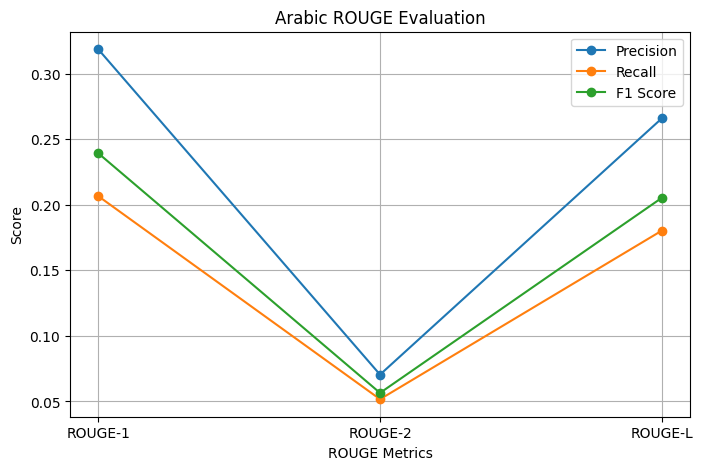

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your saved rouge file
rouge_path = r"C:\Users\omar_Addasi\Desktop\NLP_Project\results\rouge_scores_arabic_recall_focused.csv"
df = pd.read_csv(rouge_path)

# Extract values
metrics = ["rouge1", "rouge2", "rougeL"]
precision = [df[f"{m}_precision_arabic"][0] for m in metrics]
recall = [df[f"{m}_recall_arabic"][0] for m in metrics]
f1 = [df[f"{m}_f1_arabic"][0] for m in metrics]

x = range(len(metrics))

plt.figure(figsize=(8, 5))

plt.plot(x, precision, marker='o', label="Precision")
plt.plot(x, recall, marker='o', label="Recall")
plt.plot(x, f1, marker='o', label="F1 Score")

plt.xticks(x, ["ROUGE-1", "ROUGE-2", "ROUGE-L"])
plt.xlabel("ROUGE Metrics")
plt.ylabel("Score")
plt.title("Arabic ROUGE Evaluation")
plt.legend()
plt.grid(True)

plt.show()

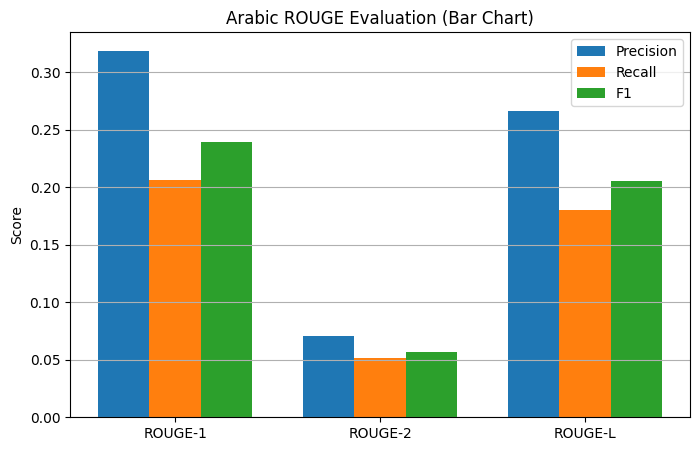

In [23]:
import numpy as np

width = 0.25
x = np.arange(len(metrics))

plt.figure(figsize=(8, 5))

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1")

plt.xticks(x, ["ROUGE-1", "ROUGE-2", "ROUGE-L"])
plt.ylabel("Score")
plt.title("Arabic ROUGE Evaluation (Bar Chart)")
plt.legend()
plt.grid(axis='y')

plt.show()

## 20. Final Test Loss

In [24]:
test_loss = evaluate(model, test_loader, criterion)
test_ppl = math.exp(test_loss) if test_loss < 20 else float("inf")

test_metrics = {
    "test_loss": test_loss,
    "test_ppl": test_ppl
}

pd.DataFrame([test_metrics]).to_csv(RESULTS_DIR / "test_loss.csv", index=False)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test PPL: {test_ppl:.2f}")
print("Saved test loss to:", (RESULTS_DIR / "test_loss.csv").resolve())


Test Loss: 6.5091
Test PPL: 671.24
Saved test loss to: C:\Users\omar_Addasi\Desktop\NLP_Project\results\test_loss.csv
